# Tableau de bord — Pêche côtière et artisanale au Maroc (2009–2025)

**Source** : rapports statistiques annuels de l'Office National des Pêches (ONP), *La pêche côtière et artisanale au Maroc*, éditions 2010 à 2025.
Les données ont été extraites de ces rapports puis consolidées dans 10 fichiers CSV (débarquements par port, par espèce et par groupe d'espèces).

**Structure du tableau de bord** — elle reprend le sommaire des rapports ONP :

| Rapport ONP | Section du notebook |
|---|---|
| I. Produits commercialisés par port / par espèce | §6.1 Vue nationale, §6.3 Ports, §6.5 Espèces |
| II. Produits commercialisés par groupe d'espèces | §6.2 Groupes d'espèces |
| III. Ventilation par région maritime (Atlantique / Méditerranée) | §6.4 Régions maritimes |

**Méthodologie suivie** : Acquisition → Inspection → Nettoyage → Transformation → Analyse → Visualisation → Conclusion.

> **Unités** : poids en **tonnes**, valeur en **KDH** (milliers de dirhams). Le prix moyen est donc `Valeur_KDH / Poids_Tonnes` = **DH/kg**.


## 0. Configuration

In [1]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda v: f"{v:,.1f}".replace(",", " "))

sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "figure.dpi": 110,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.titlepad": 12,
    "axes.edgecolor": "#cccccc",
    "grid.color": "#e6e6e6",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Palette unifiée du tableau de bord
BLEU, ORANGE, VERT, ROUGE, VIOLET, GRIS = "#1f4e79", "#e07b39", "#2e8b57", "#c0392b", "#7d5ba6", "#8c8c8c"
COUL_GROUPE = {
    "POISSON PELAGIQUE": BLEU,
    "POISSON BLANC": "#4a9ec4",
    "CEPHALOPODES": ORANGE,
    "CRUSTACES & COQUILLAGES": ROUGE,
    "ALGUES": VERT,
    "ECHINODERMES": VIOLET,
}
ORDRE_GROUPES = list(COUL_GROUPE)

def fmt_milliers(x, pos=None):
    return f"{x:,.0f}".replace(",", " ")

MILLIERS = mticker.FuncFormatter(fmt_milliers)

def fr(x, dec=2):
    """Nombre au format français : espace pour les milliers, virgule décimale."""
    return f"{x:,.{dec}f}".replace(",", " ").replace(".", ",")

def etiquettes_v(ax, x, y, dec=0, rot=90, fs=7.5, couleur="#333333", suffixe=""):
    """Écrit la valeur au-dessus de chaque point/barre et laisse de la marge en haut."""
    for xi, yi in zip(x, y):
        if pd.isna(yi):
            continue
        ax.annotate(fr(yi, dec) + suffixe, (xi, yi), xytext=(0, 4), textcoords="offset points",
                    ha="center", va="bottom", rotation=rot, fontsize=fs, color=couleur)
    bas, haut = ax.get_ylim()
    ax.set_ylim(bas, haut * 1.22 if haut > 0 else haut)

def etiquettes_h(ax, formateur, fs=8.5):
    """Valeur au bout de chaque barre horizontale ; formateur(patch, indice) -> texte."""
    xmax = ax.get_xlim()[1]
    for i, p in enumerate(ax.patches):
        ax.text(p.get_width() + xmax * 0.01, p.get_y() + p.get_height() / 2, formateur(p, i),
                va="center", fontsize=fs, color="#333333")
    ax.set_xlim(0, xmax * 1.3)
    ax.tick_params(axis="x", labelbottom=False, length=0)
    ax.grid(False)

def habiller(ax, titre=None, xlabel=None, ylabel=None, y_milliers=True):
    if titre:
        ax.set_title(titre)
    ax.set_xlabel(xlabel or "")
    ax.set_ylabel(ylabel or "")
    if y_milliers:
        ax.yaxis.set_major_formatter(MILLIERS)
    return ax

## 1. Acquisition des données

In [2]:
DOSSIER = Path(".")
if not list(DOSSIER.glob("debarquements_*.csv")):
    DOSSIER = Path("/mnt/project")   # copie de secours (fichiers du projet)

FICHIERS = {
    "ports_total": "debarquements_par_port_2010-2025.csv",
    "especes": "debarquements_par_espece_2010-2025.csv",
    "pelagique": "debarquements_poisson_pelagique_par_port_2010-2025.csv",
    "blanc": "debarquements_poisson_blanc_par_port_2010-2025.csv",
    "cephalopodes": "debarquements_cephalopodes_par_port_2010-2025.csv",
    "crust_coq": "debarquements_crustaces_coquillages_par_port_2010-2025.csv",
    "crustaces": "debarquements_crustaces_par_port_2010-2025.csv",
    "coquillages": "debarquements_coquillages_par_port_2010-2025.csv",
    "algues": "debarquements_algues_par_port_2010-2025.csv",
    "echinodermes": "debarquements_echinodermes_par_port_2010-2025.csv",
}

brut = {}
for cle, nom in FICHIERS.items():
    df = pd.read_csv(DOSSIER / nom, encoding="utf-8-sig")
    df.columns = [c.strip().lstrip("\ufeff") for c in df.columns]
    brut[cle] = df

pd.DataFrame(
    [(c, FICHIERS[c], d.shape[0], d.shape[1], d["Annee"].min(), d["Annee"].max()) for c, d in brut.items()],
    columns=["Cle", "Fichier", "Lignes", "Colonnes", "Annee_min", "Annee_max"],
)

,Cle,Fichier,Lignes,Colonnes,Annee_min,Annee_max
0,ports_total,debarquements_par_port_2010-2025.csv,1069,6,2009,2025
1,especes,debarquements_par_espece_2010-2025.csv,388,6,2009,2025
2,pelagique,debarquements_poisson_pelagique_par_port_2010-...,938,6,2009,2025
3,blanc,debarquements_poisson_blanc_par_port_2010-2025...,1002,6,2009,2025
4,cephalopodes,debarquements_cephalopodes_par_port_2010-2025.csv,1013,6,2009,2025
5,crust_coq,debarquements_crustaces_coquillages_par_port_2...,705,6,2009,2025
6,crustaces,debarquements_crustaces_par_port_2010-2025.csv,215,6,2011,2021
7,coquillages,debarquements_coquillages_par_port_2010-2025.csv,91,6,2011,2021
8,algues,debarquements_algues_par_port_2010-2025.csv,40,6,2011,2013
9,echinodermes,debarquements_echinodermes_par_port_2010-2025.csv,23,6,2011,2013


## 2. Inspection

In [3]:
apercu = brut["ports_total"]
display(apercu.head())
apercu.info()

,Port,Annee,Poids_Tonnes,Valeur_KDH,Variation_Poids,Variation_Valeur
0,AGADIR,2009,59054,346495,NaN,NaN
1,AGADIR,2010,50671,335451,-14%,-3%
2,AGADIR,2011,51449,340958,2%,2%
3,AGADIR,2012,61238,435718,19%,28%
4,AGADIR,2013,55201,439764,-10%,1%


<class 'pandas.DataFrame'>
RangeIndex: 1069 entries, 0 to 1068
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Port              1069 non-null   str  
 1   Annee             1069 non-null   int64
 2   Poids_Tonnes      1069 non-null   int64
 3   Valeur_KDH        1069 non-null   int64
 4   Variation_Poids   1015 non-null   str  
 5   Variation_Valeur  1015 non-null   str  
dtypes: int64(3), str(3)
memory usage: 50.2 KB


In [4]:
# Valeurs manquantes et nombre d'observations par année, tous fichiers confondus
manquants = pd.DataFrame({c: d.isna().sum() for c, d in brut.items()}).T
display(manquants)

couverture = pd.DataFrame({
    c: d.groupby("Annee").size() for c, d in brut.items()
}).fillna(0).astype(int)
couverture

,Annee,Espece,Poids_Tonnes,Port,Valeur_KDH,Variation_Poids,Variation_Valeur
ports_total,0.0,NaN,0.0,0.0,0.0,54.0,54.0
especes,0.0,0.0,0.0,NaN,0.0,41.0,41.0
pelagique,0.0,NaN,0.0,0.0,0.0,51.0,51.0
blanc,0.0,NaN,0.0,0.0,0.0,52.0,52.0
cephalopodes,0.0,NaN,0.0,0.0,0.0,48.0,48.0
crust_coq,0.0,NaN,0.0,0.0,0.0,46.0,46.0
crustaces,0.0,NaN,0.0,0.0,0.0,44.0,44.0
coquillages,0.0,NaN,0.0,0.0,0.0,18.0,18.0
algues,0.0,NaN,0.0,0.0,0.0,13.0,13.0
echinodermes,0.0,NaN,0.0,0.0,0.0,8.0,8.0


,ports_total,especes,pelagique,blanc,cephalopodes,crust_coq,crustaces,coquillages,algues,echinodermes
Annee,,,,,,,,,,
2009,54,41,51,52,48,46,0,0,0,0
2010,54,41,51,52,48,46,0,0,0,0
2011,53,41,51,51,48,46,44,18,13,8
2012,57,40,51,54,52,0,44,18,13,8
2013,56,40,51,53,52,0,43,19,14,7
2014,63,40,57,61,61,52,0,0,0,0
2015,66,40,60,63,64,51,0,0,0,0
2016,66,40,56,62,64,48,0,0,0,0
2017,65,8,52,60,61,45,0,0,0,0


**Constats de l'inspection**

1. Les colonnes `Variation_Poids` / `Variation_Valeur` sont des chaînes (`"-13%"`) et sont vides pour la première année de chaque série.
2. La colonne `Port` mélange des **ports** et des **agrégats** (`ATLANTIQUE`, `MEDITERRANEE`, `Total General`).
3. Les noms de ports ne sont pas orthographiés de la même façon d'un rapport à l'autre (`ASILAH`/`ASSILAH`, `MDIQ`/`M'DIQ`, `EL JADIDA`/`ELJADIDA`…).
4. Le détail **par espèce** n'existe que jusqu'en 2016 : à partir de 2017 l'ONP ne publie plus que les groupes d'espèces.
5. Crustacés et coquillages sont tantôt publiés ensemble, tantôt séparément selon l'année.

## 3. Nettoyage

In [5]:
AGREGATS = {"ATLANTIQUE", "MEDITERRANEE", "TOTALGENERAL", "TOTALGENERAL()"}

ALIAS_PORTS = {            # variantes orthographiques d'un même port
    "ASSILAH": "ASILAH",
    "HOCEIMA": "ALHOCEIMA",
    "RASKEBDANA": "RASKABDANA",
    "RKOUNT": "RKOUNTE",
    "NTIRIFT": "NTIREFT",
    "SIDELGHAZI": "SIDIELGHAZI",
    "MYBOUSSELHAM": "MOULAYBOUSSELHAM",
    "MOULAYBOUSSELHA": "MOULAYBOUSSELHAM",
}

def cle_port(nom: str) -> str:
    """Clé canonique : majuscules, sans espaces ni ponctuation, alias résolus."""
    k = re.sub(r"[^A-Z0-9()]", "", str(nom).upper())
    return ALIAS_PORTS.get(k, k)

def pourcent_en_float(s):
    return pd.to_numeric(
        s.astype(str).str.replace("%", "", regex=False).str.replace(" ", "", regex=False).str.replace(",", "."),
        errors="coerce",
    )

def nettoyer(df, colonne_cle="Port"):
    d = df.copy()
    d[colonne_cle] = d[colonne_cle].astype(str).str.strip().str.upper()
    d["Annee"] = d["Annee"].astype(int)
    for c in ("Poids_Tonnes", "Valeur_KDH"):
        d[c] = pd.to_numeric(d[c], errors="coerce").fillna(0).astype(float)
    d["Variation_Poids"] = pourcent_en_float(d["Variation_Poids"])
    d["Variation_Valeur"] = pourcent_en_float(d["Variation_Valeur"])
    if colonne_cle == "Port":
        d["Cle_Port"] = d["Port"].map(cle_port)
        d["Est_Agregat"] = d["Cle_Port"].isin(AGREGATS)
    return d.drop_duplicates()

propre = {c: nettoyer(d, "Espece" if c == "especes" else "Port") for c, d in brut.items()}

# Libellé d'affichage = orthographe la plus fréquente rencontrée dans les rapports
toutes_lignes = pd.concat([d for c, d in propre.items() if c != "especes"], ignore_index=True)
LIBELLE = (toutes_lignes[~toutes_lignes["Est_Agregat"]]
           .groupby(["Cle_Port", "Port"]).size().rename("n").reset_index()
           .sort_values(["Cle_Port", "n"], ascending=[True, False])
           .drop_duplicates("Cle_Port").set_index("Cle_Port")["Port"].str.title().to_dict())

print(f"{len(LIBELLE)} ports distincts après normalisation "
      f"(contre {toutes_lignes.loc[~toutes_lignes['Est_Agregat'], 'Port'].nunique()} orthographes brutes)")

68 ports distincts après normalisation (contre 87 orthographes brutes)


In [6]:
# Contrôle : aucune paire (port, année) dupliquée après normalisation
pt = propre["ports_total"]
doublons = pt[~pt["Est_Agregat"]].groupby(["Cle_Port", "Annee"]).size()
print("Doublons (port, annee) :", int((doublons > 1).sum()))

# Les agrégats sont isolés dans une table de contrôle
totaux_officiels = (pt[pt["Est_Agregat"]]
                    .pivot_table(index="Annee", columns="Cle_Port",
                                 values=["Poids_Tonnes", "Valeur_KDH"], aggfunc="sum"))
totaux_officiels.head()

Doublons (port, annee) : 0


Poids_Tonnes                            Valeur_KDH               \
Cle_Port   ATLANTIQUE MEDITERRANEE TOTALGENERAL  ATLANTIQUE MEDITERRANEE   
Annee                                                                      
2009      1 028 360.0     38 917.0  1 067 277.0 3 891 556.0    364 799.0   
2010      1 053 574.0     32 675.0  1 086 249.0 3 851 310.0    374 078.0   
2011        882 487.0     25 771.0    908 258.0 4 617 158.0    393 599.0   
2012      1 090 005.0     26 645.0  1 116 650.0 4 799 617.0    319 497.0   
2013      1 139 018.0     33 955.0  1 172 973.0 5 048 548.0    400 359.0   

                       
Cle_Port TOTALGENERAL  
Annee                  
2009      4 256 355.0  
2010      4 225 388.0  
2011      5 010 757.0  
2012      5 119 114.0  
2013      5 448 907.0

### 3.1 Rattachement des ports à leur région maritime

Les CSV ne contiennent pas de colonne région : elle est reconstituée à partir du classement des rapports ONP,
puis **validée** en comparant la somme des ports aux lignes agrégées `ATLANTIQUE` / `MEDITERRANEE`.

In [7]:
PORTS_MEDITERRANEE = {
    "AMTAR", "BELYOUNECH", "CALAIRIS", "CHMAALA", "DALIA", "FNIDEQ", "ALHOCEIMA", "INOUAREN",
    "JEBHA", "KAAASRAS", "KSARSGHIR", "MARTIL", "MDIQ", "NADOR", "OUEDLAOU", "RASKABDANA",
    "SIDIHSAINE", "TANGER", "TARGHA",
}

def region(cle, annee):
    # Jusqu'au rapport 2016, TANGER était comptabilisé dans la façade atlantique.
    if cle == "TANGER":
        return "MEDITERRANEE" if annee >= 2017 else "ATLANTIQUE"
    return "MEDITERRANEE" if cle in PORTS_MEDITERRANEE else "ATLANTIQUE"

ports = pt[~pt["Est_Agregat"]].copy()
ports["Region"] = [region(k, a) for k, a in zip(ports["Cle_Port"], ports["Annee"])]

controle = (ports.pivot_table(index="Annee", columns="Region", values="Poids_Tonnes", aggfunc="sum")
            .join(totaux_officiels["Poids_Tonnes"], rsuffix="_officiel"))
controle["Ecart_Atl"] = controle["ATLANTIQUE"] - controle["ATLANTIQUE_officiel"]
controle["Ecart_Med"] = controle["MEDITERRANEE"] - controle["MEDITERRANEE_officiel"]
controle[["ATLANTIQUE", "ATLANTIQUE_officiel", "Ecart_Atl", "MEDITERRANEE", "MEDITERRANEE_officiel", "Ecart_Med"]]

,ATLANTIQUE,ATLANTIQUE_officiel,Ecart_Atl,MEDITERRANEE,MEDITERRANEE_officiel,Ecart_Med
Annee,,,,,,
2009,1 028 350.0,1 028 360.0,-10.0,38 926.0,38 917.0,9.0
2010,1 053 446.0,1 053 574.0,-128.0,32 800.0,32 675.0,125.0
2011,882 382.0,882 487.0,-105.0,25 877.0,25 771.0,106.0
2012,1 089 846.0,1 090 005.0,-159.0,26 805.0,26 645.0,160.0
2013,1 139 019.0,1 139 018.0,1.0,33 957.0,33 955.0,2.0
2014,1 256 208.0,1 256 209.0,-1.0,30 971.0,30 970.0,1.0
2015,1 262 613.0,1 262 614.0,-1.0,26 337.0,26 334.0,3.0
2016,1 360 832.0,1 360 835.0,-3.0,22 380.0,22 380.0,0.0
2017,1 285 568.0,1 285 571.0,-3.0,24 923.0,24 925.0,-2.0


L'écart résiduel est de quelques tonnes par an (arrondis des rapports), soit **moins de 0,001 %** : le rattachement est fiable.
Sans la correction sur Tanger, l'écart atteindrait 8 000 à 13 000 tonnes par an sur la période 2009–2016.

## 4. Transformation

### 4.1 Table consolidée des groupes d'espèces

Règle appliquée pour éviter les doubles comptes : lorsqu'une année dispose à la fois du fichier
combiné `crustaces_coquillages` et des fichiers séparés, **le fichier combiné fait foi**.

In [8]:
annees_combine = set(propre["crust_coq"]["Annee"].unique())

def preparer_groupe(cle, libelle, annees=None):
    d = propre[cle]
    d = d[~d["Est_Agregat"]].copy()
    if annees is not None:
        d = d[d["Annee"].isin(annees)]
    d["Groupe"] = libelle
    return d[["Cle_Port", "Annee", "Groupe", "Poids_Tonnes", "Valeur_KDH"]]

morceaux = [
    preparer_groupe("pelagique", "POISSON PELAGIQUE"),
    preparer_groupe("blanc", "POISSON BLANC"),
    preparer_groupe("cephalopodes", "CEPHALOPODES"),
    preparer_groupe("crust_coq", "CRUSTACES & COQUILLAGES"),
    preparer_groupe("crustaces", "CRUSTACES & COQUILLAGES",
                    annees=set(propre["crustaces"]["Annee"]) - annees_combine),
    preparer_groupe("coquillages", "CRUSTACES & COQUILLAGES",
                    annees=set(propre["coquillages"]["Annee"]) - annees_combine),
    preparer_groupe("algues", "ALGUES"),
    preparer_groupe("echinodermes", "ECHINODERMES"),
]

groupes = (pd.concat(morceaux, ignore_index=True)
           .groupby(["Cle_Port", "Annee", "Groupe"], as_index=False)[["Poids_Tonnes", "Valeur_KDH"]].sum())
groupes["Port"] = groupes["Cle_Port"].map(LIBELLE)
groupes["Region"] = [region(k, a) for k, a in zip(groupes["Cle_Port"], groupes["Annee"])]
groupes["Valeur_MDH"] = groupes["Valeur_KDH"] / 1000
groupes["Prix_DH_kg"] = np.where(groupes["Poids_Tonnes"] > 0,
                                 groupes["Valeur_KDH"] / groupes["Poids_Tonnes"], np.nan)
groupes.head()

,Cle_Port,Annee,Groupe,Poids_Tonnes,Valeur_KDH,Port,Region,Valeur_MDH,Prix_DH_kg
0,AGADIR,2009,CEPHALOPODES,1 497.0,37 218.0,Agadir,ATLANTIQUE,37.2,24.9
1,AGADIR,2009,CRUSTACES & COQUILLAGES,1 157.0,40 734.0,Agadir,ATLANTIQUE,40.7,35.2
2,AGADIR,2009,POISSON BLANC,18 330.0,173 674.0,Agadir,ATLANTIQUE,173.7,9.5
3,AGADIR,2009,POISSON PELAGIQUE,38 071.0,94 868.0,Agadir,ATLANTIQUE,94.9,2.5
4,AGADIR,2010,CEPHALOPODES,950.0,29 506.0,Agadir,ATLANTIQUE,29.5,31.1


In [9]:
# Cohérence : la somme des groupes doit approcher le total par port
verif = (groupes.groupby("Annee")["Poids_Tonnes"].sum()
         .to_frame("Somme_groupes")
         .join(ports.groupby("Annee")["Poids_Tonnes"].sum().rename("Total_ports")))
verif["Ecart_%"] = 100 * (verif["Somme_groupes"] - verif["Total_ports"]) / verif["Total_ports"]
verif.round(2)

,Somme_groupes,Total_ports,Ecart_%
Annee,,,
2009,1 067 278.0,1 067 276.0,0.0
2010,1 069 354.0,1 086 246.0,-1.6
2011,914 718.0,908 259.0,0.7
2012,1 116 647.0,1 116 651.0,-0.0
2013,1 172 967.0,1 172 976.0,-0.0
2014,1 277 547.0,1 287 179.0,-0.8
2015,1 269 965.0,1 288 950.0,-1.5
2016,1 357 822.0,1 383 212.0,-1.8
2017,1 285 784.0,1 310 491.0,-1.9


L'écart reste compris entre **-3,2 % et +0,7 %** : les groupes publiés port par port ne recouvrent pas exactement le
total par port (les algues, échinodermes et rubriques « divers » ne sont ventilés par port que sur quelques années,
et ne sont pas toujours repris dans le tableau général). Les analyses par groupe sont donc lues en **structure**
(parts relatives) et les niveaux absolus sont pris dans la table `ports`.

### 4.2 Tables d'analyse

In [10]:
# Table ports enrichie
ports["Port"] = ports["Cle_Port"].map(LIBELLE)
ports["Prix_DH_kg"] = np.where(ports["Poids_Tonnes"] > 0, ports["Valeur_KDH"] / ports["Poids_Tonnes"], np.nan)
ports["Valeur_MDH"] = ports["Valeur_KDH"] / 1000          # millions de dirhams

# Série nationale
national = (ports.groupby("Annee")[["Poids_Tonnes", "Valeur_KDH"]].sum()
            .assign(Prix_DH_kg=lambda d: d["Valeur_KDH"] / d["Poids_Tonnes"]))
national["Valeur_MDH"] = national["Valeur_KDH"] / 1000
national["Var_Poids_%"] = national["Poids_Tonnes"].pct_change() * 100
national["Var_Valeur_%"] = national["Valeur_KDH"].pct_change() * 100

# Espèces (détail disponible jusqu'en 2016 seulement)
NIVEAU_GROUPE = {"POISSON PELAGIQUE", "POISSON PELAGIQUES", "POISSON BLANC", "CEPHALOPODES",
                 "CRUSTACES", "COQUILLAGES", "ALGUES", "ECHINODERMES-OURSINS", "AUTRES", "TOTAL GENERAL"}
esp = propre["especes"].copy()
esp["Niveau"] = np.where(esp["Espece"].isin(NIVEAU_GROUPE), "groupe", "espece")
especes = esp[esp["Niveau"] == "espece"].copy()
especes["Prix_DH_kg"] = np.where(especes["Poids_Tonnes"] > 0,
                                 especes["Valeur_KDH"] / especes["Poids_Tonnes"], np.nan)
especes["Valeur_MDH"] = especes["Valeur_KDH"] / 1000

ANNEES = sorted(national.index)
A_DEB, A_FIN = ANNEES[0], ANNEES[-1]
print(f"Période couverte : {A_DEB}–{A_FIN} | {ports['Cle_Port'].nunique()} ports | "
      f"{especes['Espece'].nunique()} espèces détaillées ({especes['Annee'].min()}–{especes['Annee'].max()})")

Période couverte : 2009–2025 | 68 ports | 32 espèces détaillées (2009–2016)


## 5. Analyse

In [11]:
def tcam(serie):
    """Taux de croissance annuel moyen (%)."""
    n = len(serie) - 1
    return ((serie.iloc[-1] / serie.iloc[0]) ** (1 / n) - 1) * 100

def hhi(valeurs):
    """Indice de Herfindahl-Hirschman (0–10 000) : concentration des débarquements."""
    p = valeurs / valeurs.sum()
    return float((p ** 2).sum() * 10_000)

kpi = {
    "Poids (t) " + str(A_FIN): national.loc[A_FIN, "Poids_Tonnes"],
    "Valeur (MDH) " + str(A_FIN): national.loc[A_FIN, "Valeur_MDH"],
    "Prix moyen " + str(A_FIN): national.loc[A_FIN, "Prix_DH_kg"],
    "Var. poids vs " + str(A_FIN - 1): national.loc[A_FIN, "Var_Poids_%"],
    "Var. valeur vs " + str(A_FIN - 1): national.loc[A_FIN, "Var_Valeur_%"],
    "TCAM poids": tcam(national["Poids_Tonnes"]),
    "TCAM valeur": tcam(national["Valeur_KDH"]),
    "HHI ports " + str(A_FIN): hhi(ports.loc[ports["Annee"] == A_FIN, "Poids_Tonnes"]),
}
pd.Series(kpi).round(2)

Poids (t) 2025        1 132 802.0
Valeur (MDH) 2025        10 111.9
Prix moyen 2025               8.9
Var. poids vs 2024          -15.2
Var. valeur vs 2024          -4.1
TCAM poids                    0.4
TCAM valeur                   5.6
HHI ports 2025            1 444.7
dtype: float64

In [12]:
# Top 10 des ports de l'année la plus récente
top_ports = (ports[ports["Annee"] == A_FIN]
             .sort_values("Poids_Tonnes", ascending=False)
             .head(10)[["Port", "Region", "Poids_Tonnes", "Valeur_MDH", "Prix_DH_kg", "Variation_Poids"]]
             .reset_index(drop=True))
top_ports["Part_%"] = 100 * top_ports["Poids_Tonnes"] / national.loc[A_FIN, "Poids_Tonnes"]
top_ports.round(1)

,Port,Region,Poids_Tonnes,Valeur_MDH,Prix_DH_kg,Variation_Poids,Part_%
0,Dakhla(Stock C),ATLANTIQUE,326 284.0,755.4,2.3,-35.0,28.8
1,Laayoune,ATLANTIQUE,209 954.0,1 564.7,7.5,17.0,18.5
2,Dakhla,ATLANTIQUE,117 017.0,1 002.8,8.6,-29.0,10.3
3,Tan Tan,ATLANTIQUE,93 063.0,1 046.0,11.2,65.0,8.2
4,Boujdour,ATLANTIQUE,67 236.0,568.0,8.4,-10.0,5.9
5,Safi,ATLANTIQUE,54 801.0,350.9,6.4,7.0,4.8
6,Agadir,ATLANTIQUE,39 002.0,358.1,9.2,-13.0,3.4
7,Sidi Ifni,ATLANTIQUE,26 427.0,193.3,7.3,-58.0,2.3
8,Tarfaya,ATLANTIQUE,26 101.0,381.0,14.6,43.0,2.3
9,Jorf Lasfar,ATLANTIQUE,20 156.0,98.4,4.9,1.0,1.8


In [13]:
# Poids et valeur par groupe d'espèces sur la dernière année
bilan_groupes = (groupes[groupes["Annee"] == A_FIN]
                 .groupby("Groupe")[["Poids_Tonnes", "Valeur_KDH"]].sum())
bilan_groupes["Part_poids_%"] = 100 * bilan_groupes["Poids_Tonnes"] / bilan_groupes["Poids_Tonnes"].sum()
bilan_groupes["Part_valeur_%"] = 100 * bilan_groupes["Valeur_KDH"] / bilan_groupes["Valeur_KDH"].sum()
bilan_groupes["Prix_DH_kg"] = bilan_groupes["Valeur_KDH"] / bilan_groupes["Poids_Tonnes"]
bilan_groupes["Valeur_MDH"] = bilan_groupes["Valeur_KDH"] / 1000
bilan_groupes.sort_values("Poids_Tonnes", ascending=False).round(1)

,Poids_Tonnes,Valeur_KDH,Part_poids_%,Part_valeur_%,Prix_DH_kg,Valeur_MDH
Groupe,,,,,,
POISSON PELAGIQUE,909 746.0,3 521 539.0,82.3,35.1,3.9,3 521.5
POISSON BLANC,137 570.0,1 967 883.0,12.4,19.6,14.3,1 967.9
CEPHALOPODES,49 875.0,4 116 917.0,4.5,41.0,82.5,4 116.9
CRUSTACES & COQUILLAGES,8 595.0,426 522.0,0.8,4.3,49.6,426.5


In [14]:
# Espèces : classement de la dernière année détaillée (2016)
A_ESP = int(especes["Annee"].max())
top_especes = (especes[especes["Annee"] == A_ESP]
               .sort_values("Poids_Tonnes", ascending=False)
               .head(12)[["Espece", "Poids_Tonnes", "Valeur_MDH", "Prix_DH_kg"]]
               .reset_index(drop=True))
top_especes.round(1)

,Espece,Poids_Tonnes,Valeur_MDH,Prix_DH_kg
0,SARDINE,912 218.0,1 807.4,2.0
1,MAQUEREAU,206 062.0,431.3,2.1
2,CHINCHARD,36 929.0,147.5,4.0
3,POULPE,23 682.0,1 354.8,57.2
4,ANCHOIS,17 501.0,92.2,5.3
5,BOGUE,6 866.0,55.8,8.1
6,SABRE,5 959.0,53.8,9.0
7,CALMAR,3 927.0,195.9,49.9
8,GRONDIN,3 766.0,34.9,9.3
9,LANGUE,3 674.0,85.3,23.2


## 6. Tableau de bord (visualisation)

Convention de lecture : **poids en tonnes**, **valeur en MDH** (millions de dirhams = `Valeur_KDH / 1 000`), prix moyen en DH/kg.
Chaque graphique porte ses valeurs chiffrées directement sur les barres et les courbes.

### 6.0 Synthèse

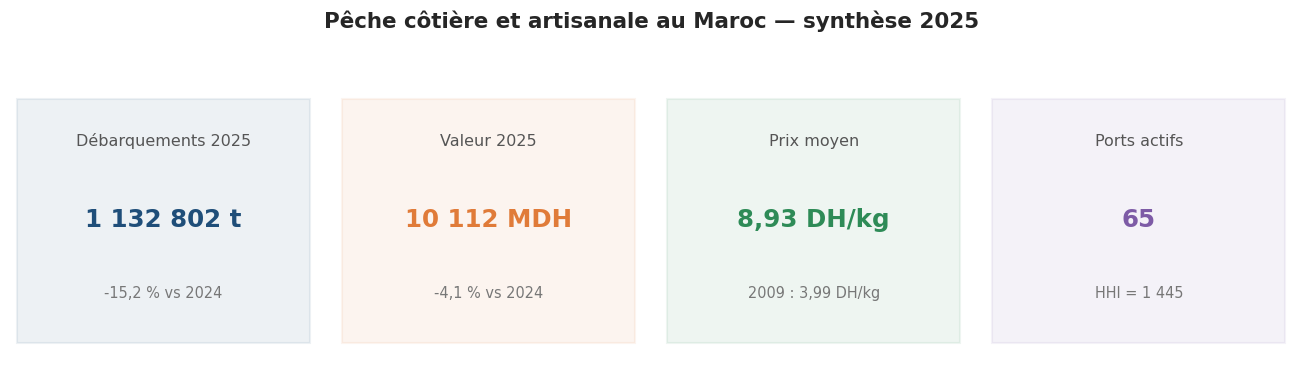

In [15]:
fig = plt.figure(figsize=(12, 3.2))
cartes = [
    (f"Débarquements {A_FIN}", f"{fr(national.loc[A_FIN, 'Poids_Tonnes'], 0)} t",
     f"{fr(national.loc[A_FIN, 'Var_Poids_%'], 1)} % vs {A_FIN-1}", BLEU),
    (f"Valeur {A_FIN}", f"{fr(national.loc[A_FIN, 'Valeur_MDH'], 0)} MDH",
     f"{fr(national.loc[A_FIN, 'Var_Valeur_%'], 1)} % vs {A_FIN-1}", ORANGE),
    ("Prix moyen", f"{fr(national.loc[A_FIN, 'Prix_DH_kg'])} DH/kg",
     f"{A_DEB} : {fr(national.loc[A_DEB, 'Prix_DH_kg'])} DH/kg", VERT),
    ("Ports actifs", f"{ports[(ports.Annee==A_FIN) & (ports.Poids_Tonnes>0)]['Cle_Port'].nunique()}",
     f"HHI = {fr(hhi(ports.loc[ports.Annee==A_FIN,'Poids_Tonnes']), 0)}", VIOLET),
]
for i, (titre, valeur, note, couleur) in enumerate(cartes):
    ax = fig.add_subplot(1, 4, i + 1)
    ax.axis("off")
    ax.add_patch(plt.Rectangle((0.02, 0.05), 0.96, 0.9, facecolor=couleur, alpha=0.08,
                               edgecolor=couleur, linewidth=1.4, transform=ax.transAxes))
    ax.text(0.5, 0.78, titre, ha="center", transform=ax.transAxes, fontsize=10.5, color="#555555")
    ax.text(0.5, 0.48, valeur, ha="center", transform=ax.transAxes, fontsize=16, fontweight="bold", color=couleur)
    ax.text(0.5, 0.22, note, ha="center", transform=ax.transAxes, fontsize=9.5, color="#777777")
fig.suptitle(f"Pêche côtière et artisanale au Maroc — synthèse {A_FIN}", fontsize=14, fontweight="bold", y=1.04)
plt.tight_layout()
plt.show()

### 6.1 Vue nationale

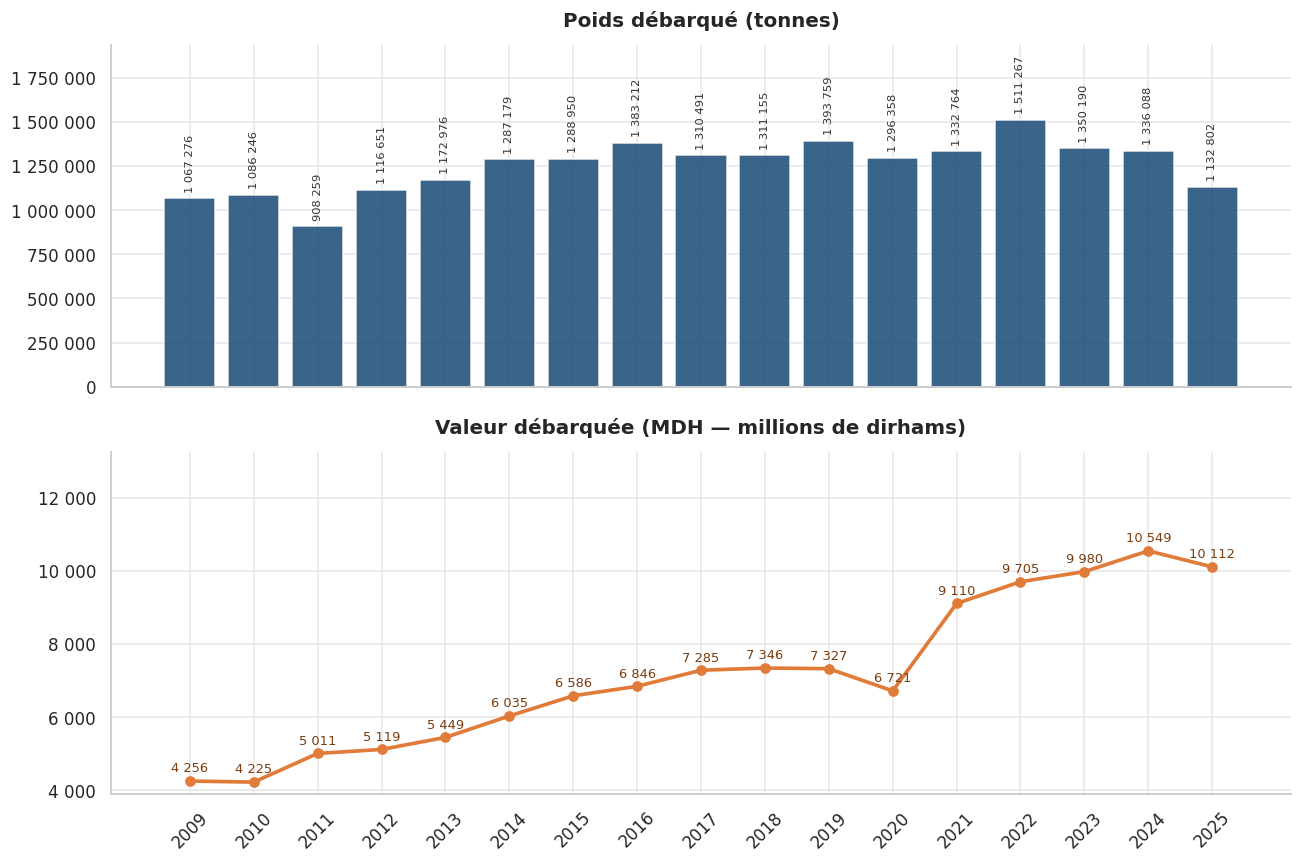

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].bar(national.index, national["Poids_Tonnes"], color=BLEU, alpha=0.88)
etiquettes_v(axes[0], national.index, national["Poids_Tonnes"].values)
axes[0].yaxis.set_major_formatter(MILLIERS)
axes[0].set_title("Poids débarqué (tonnes)")
axes[1].plot(national.index, national["Valeur_MDH"], color=ORANGE, marker="o", lw=2.4)
etiquettes_v(axes[1], national.index, national["Valeur_MDH"].values, couleur="#7a3d10", rot=0, fs=8.5)
axes[1].yaxis.set_major_formatter(MILLIERS)
axes[1].set_title("Valeur débarquée (MDH — millions de dirhams)")
axes[1].set_xticks(national.index)
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

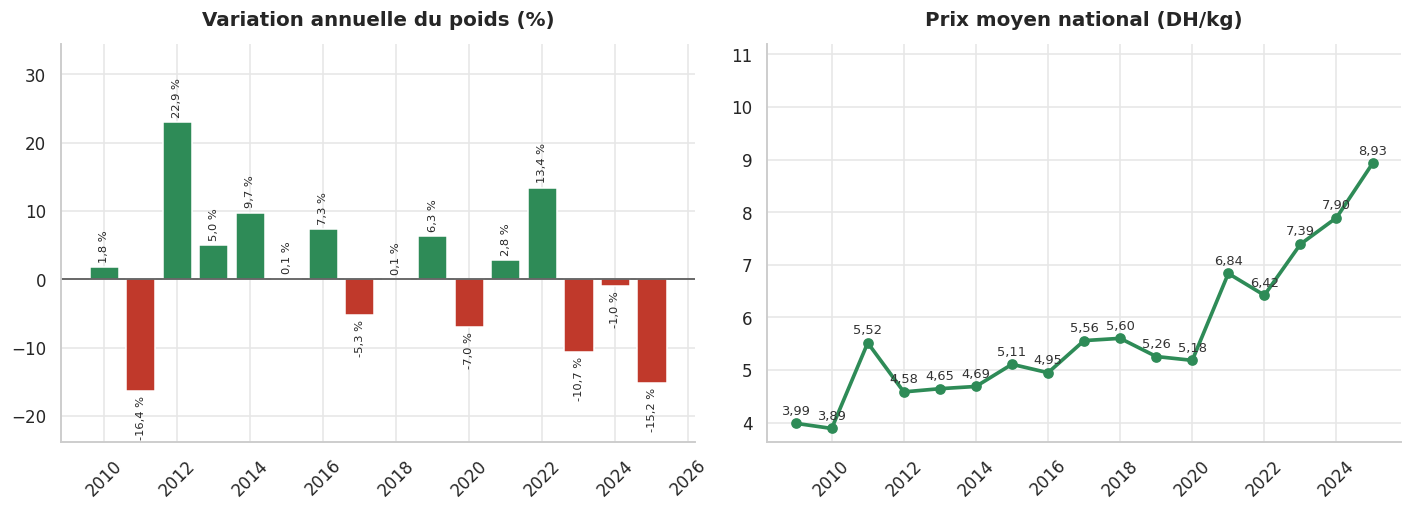

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
v = national["Var_Poids_%"].dropna()
axes[0].bar(v.index, v.values, color=[VERT if x >= 0 else ROUGE for x in v.values])
axes[0].axhline(0, color="#444444", lw=1)
for xi, yi in zip(v.index, v.values):
    axes[0].annotate(f"{fr(yi, 1)} %", (xi, yi), xytext=(0, 3 if yi >= 0 else -3), textcoords="offset points",
                     ha="center", va="bottom" if yi >= 0 else "top", fontsize=7.5, rotation=90)
axes[0].set_ylim(v.min() * 1.45, v.max() * 1.5)
axes[0].set_title("Variation annuelle du poids (%)")
axes[1].plot(national.index, national["Prix_DH_kg"], color=VERT, marker="o", lw=2.4)
etiquettes_v(axes[1], national.index, national["Prix_DH_kg"].values, dec=2, rot=0, fs=8.5)
axes[1].set_title("Prix moyen national (DH/kg)")
for a in axes:
    a.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

### 6.2 Groupes d'espèces

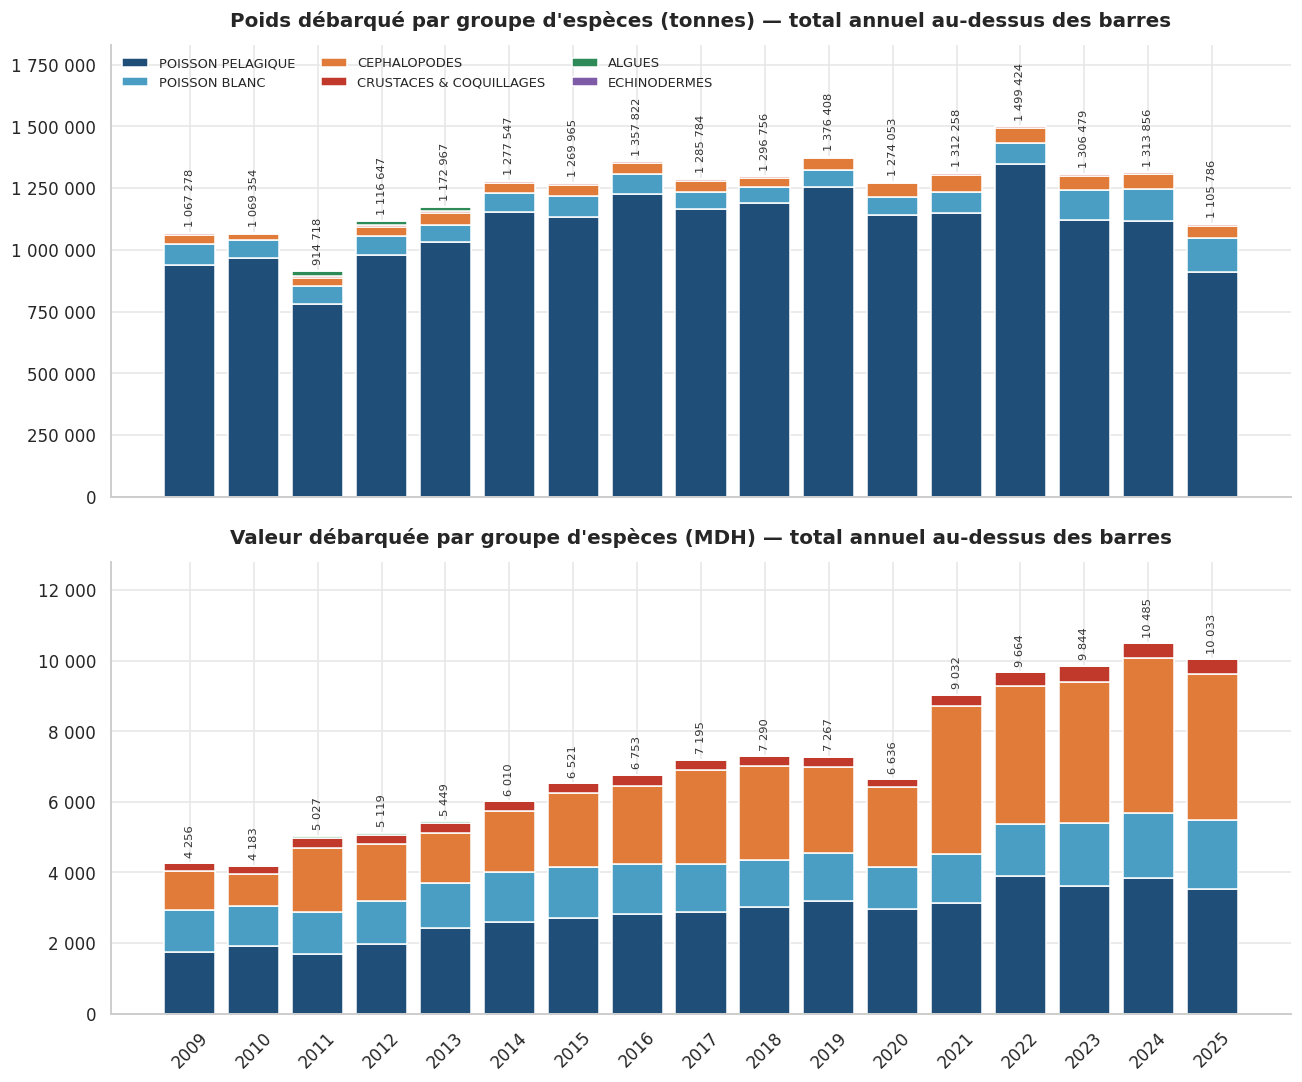

In [18]:
pivot_poids = (groupes.pivot_table(index="Annee", columns="Groupe", values="Poids_Tonnes", aggfunc="sum")
               .fillna(0).reindex(columns=[g for g in ORDRE_GROUPES if g in groupes["Groupe"].unique()]))
pivot_mdh = (groupes.pivot_table(index="Annee", columns="Groupe", values="Valeur_MDH", aggfunc="sum")
             .fillna(0).reindex(columns=pivot_poids.columns))

def empiler(ax, pivot, titre):
    bas = np.zeros(len(pivot))
    for c in pivot.columns:
        ax.bar(pivot.index, pivot[c], bottom=bas, color=COUL_GROUPE[c], label=c)
        bas += pivot[c].values
    etiquettes_v(ax, pivot.index, bas, fs=7.5)
    ax.yaxis.set_major_formatter(MILLIERS)
    ax.set_title(titre)
    ax.set_xticks(pivot.index)
    ax.tick_params(axis="x", rotation=45)

fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
empiler(axes[0], pivot_poids, "Poids débarqué par groupe d'espèces (tonnes) — total annuel au-dessus des barres")
axes[0].legend(loc="upper left", ncol=3, fontsize=8.5, frameon=False)
empiler(axes[1], pivot_mdh, "Valeur débarquée par groupe d'espèces (MDH) — total annuel au-dessus des barres")
plt.tight_layout()
plt.show()

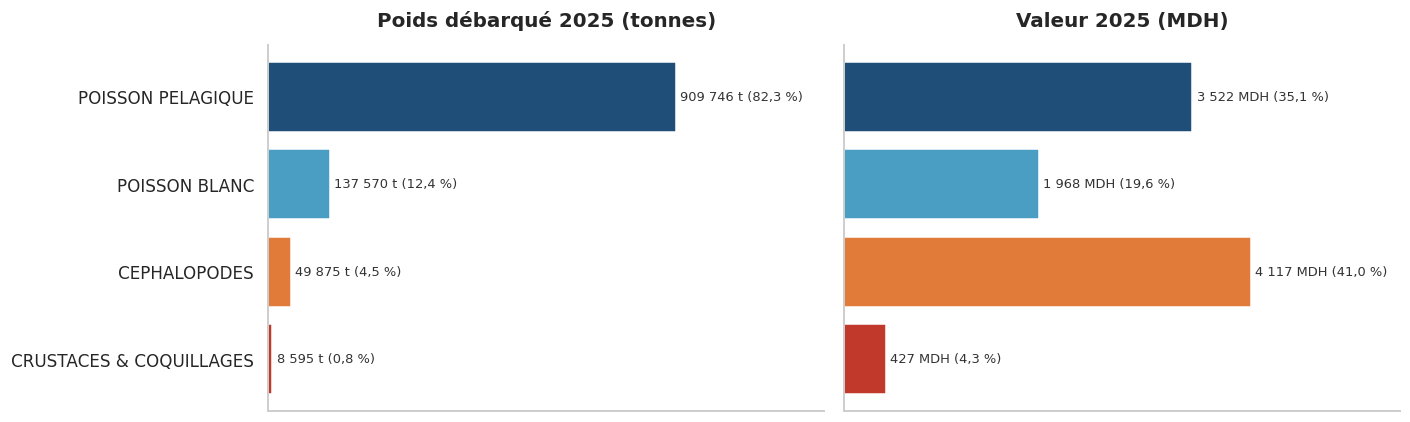

In [19]:
b = bilan_groupes.sort_values("Poids_Tonnes", ascending=True)
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
coul = [COUL_GROUPE[i] for i in b.index]
axes[0].barh(b.index, b["Poids_Tonnes"], color=coul)
axes[0].set_title(f"Poids débarqué {A_FIN} (tonnes)")
axes[1].barh(b.index, b["Valeur_MDH"], color=coul)
axes[1].set_title(f"Valeur {A_FIN} (MDH)")
parts_p, parts_v = list(b["Part_poids_%"]), list(b["Part_valeur_%"])
etiquettes_h(axes[0], lambda p, i: f"{fr(p.get_width(), 0)} t ({fr(parts_p[i], 1)} %)")
etiquettes_h(axes[1], lambda p, i: f"{fr(p.get_width(), 0)} MDH ({fr(parts_v[i], 1)} %)")
plt.tight_layout()
plt.show()

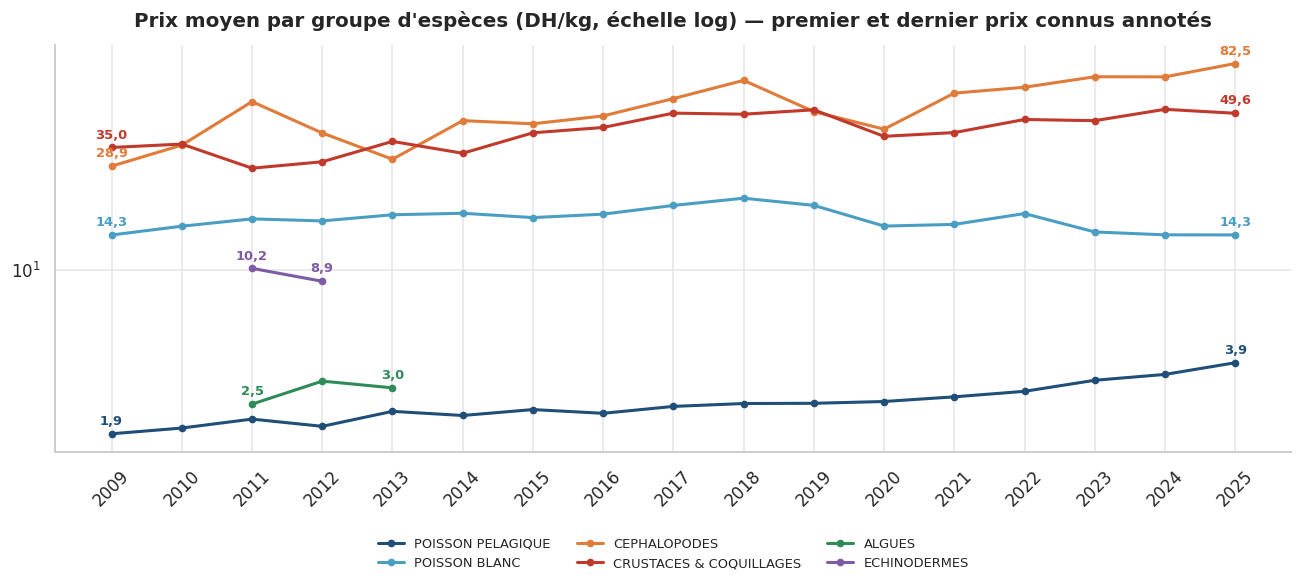

In [20]:
prix = (groupes.groupby(["Annee", "Groupe"])[["Poids_Tonnes", "Valeur_KDH"]].sum()
        .assign(Prix=lambda d: d["Valeur_KDH"] / d["Poids_Tonnes"])
        .reset_index().pivot(index="Annee", columns="Groupe", values="Prix"))
fig, ax = plt.subplots(figsize=(12, 5.6))
for c in [c for c in pivot_poids.columns if c in prix]:
    serie = prix[c].dropna()
    ax.plot(serie.index, serie.values, marker="o", ms=4, lw=2, color=COUL_GROUPE[c], label=c)
    for xi in (serie.index[0], serie.index[-1]):
        ax.annotate(fr(serie[xi], 1), (xi, serie[xi]), xytext=(0, 6), textcoords="offset points",
                    ha="center", fontsize=8.5, color=COUL_GROUPE[c], fontweight="bold")
ax.set_yscale("log")
ax.set_title("Prix moyen par groupe d'espèces (DH/kg, échelle log) — premier et dernier prix connus annotés")
ax.legend(fontsize=8.5, frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3)
ax.set_xticks(prix.index)
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

### 6.3 Ports

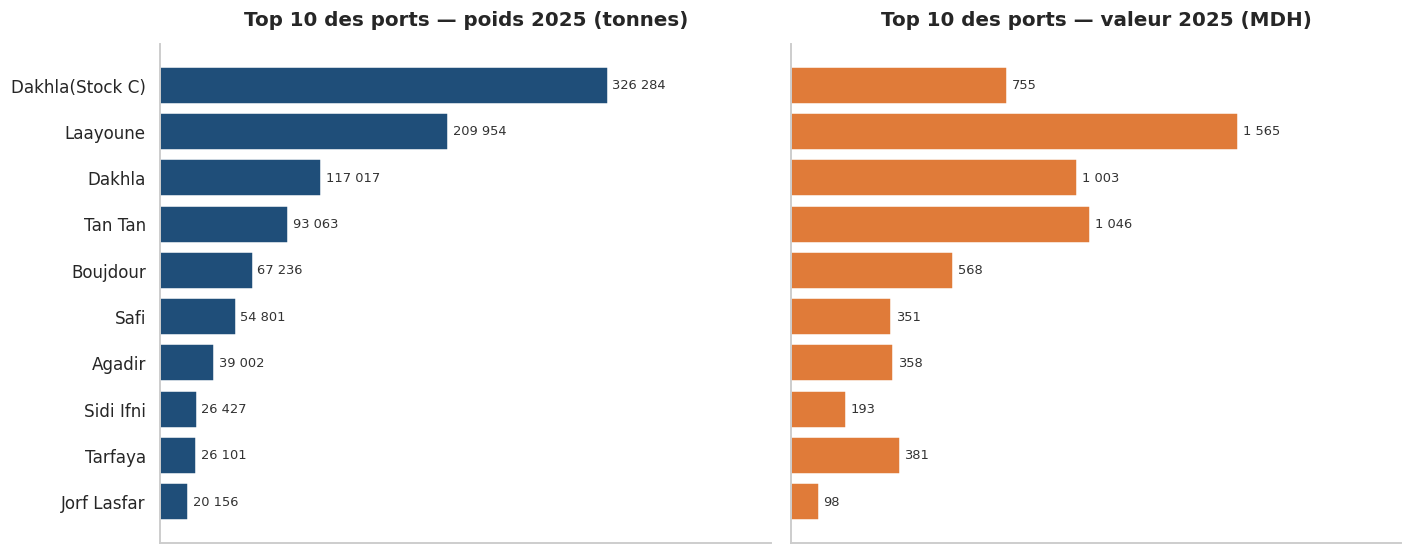

In [21]:
t = top_ports.sort_values("Poids_Tonnes")
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), sharey=True)
axes[0].barh(t["Port"], t["Poids_Tonnes"], color=BLEU)
axes[0].set_title(f"Top 10 des ports — poids {A_FIN} (tonnes)")
axes[1].barh(t["Port"], t["Valeur_MDH"], color=ORANGE)
axes[1].set_title(f"Top 10 des ports — valeur {A_FIN} (MDH)")
etiquettes_h(axes[0], lambda p, i: fr(p.get_width(), 0))
etiquettes_h(axes[1], lambda p, i: fr(p.get_width(), 0))
plt.tight_layout()
plt.show()

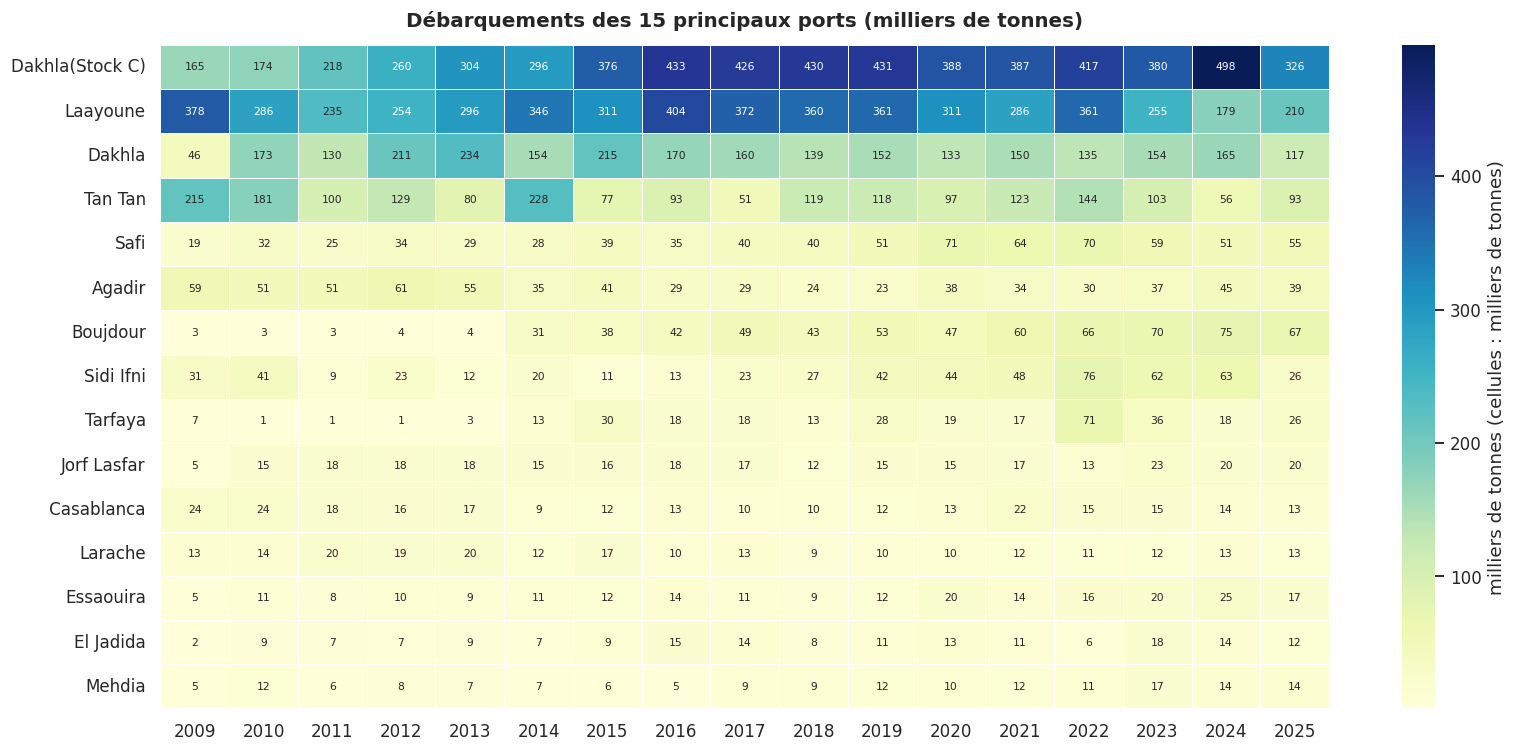

In [22]:
principaux = ports.groupby("Port")["Poids_Tonnes"].sum().nlargest(15).index
heat = (ports[ports["Port"].isin(principaux)]
        .pivot_table(index="Port", columns="Annee", values="Poids_Tonnes", aggfunc="sum")
        .reindex(principaux).fillna(0))

fig, ax = plt.subplots(figsize=(15, 7))
sns.heatmap(heat / 1000, cmap="YlGnBu", linewidths=0.4, linecolor="white",
            annot=heat.div(1000).round(0).astype(int).map(lambda x: fr(x, 0)).values, fmt="", annot_kws={"fontsize": 7},
            cbar_kws={"label": "milliers de tonnes (cellules : milliers de tonnes)"}, ax=ax)
ax.set_title("Débarquements des 15 principaux ports (milliers de tonnes)")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

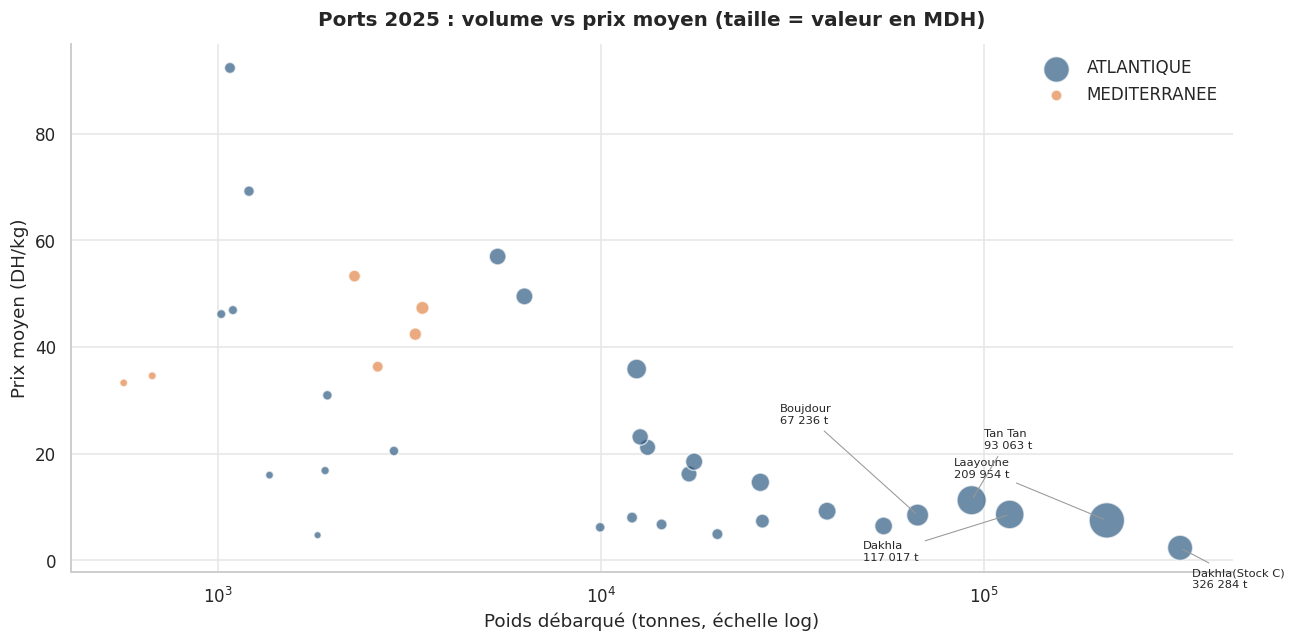

In [23]:
p = ports[(ports["Annee"] == A_FIN) & (ports["Poids_Tonnes"] > 500)].copy()
fig, ax = plt.subplots(figsize=(12, 6))
couleurs = {"ATLANTIQUE": BLEU, "MEDITERRANEE": ORANGE}
for reg, sub in p.groupby("Region"):
    ax.scatter(sub["Poids_Tonnes"], sub["Prix_DH_kg"], s=sub["Valeur_MDH"] / 3 + 20,
               alpha=0.65, color=couleurs[reg], edgecolor="white", label=reg)
decalages = [(8, -26), (-100, 28), (-96, -30), (8, 34), (-90, 60)]
for (_, r), dec in zip(p.nlargest(5, "Poids_Tonnes").iterrows(), decalages):
    ax.annotate(f"{r['Port']}\n{fr(r['Poids_Tonnes'], 0)} t",
                (r["Poids_Tonnes"], r["Prix_DH_kg"]), fontsize=7.5, xytext=dec, textcoords="offset points",
                arrowprops=dict(arrowstyle="-", color="#999999", lw=0.7))
ax.set_xscale("log")
ax.set_title(f"Ports {A_FIN} : volume vs prix moyen (taille = valeur en MDH)")
ax.set_xlabel("Poids débarqué (tonnes, échelle log)")
ax.set_ylabel("Prix moyen (DH/kg)")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

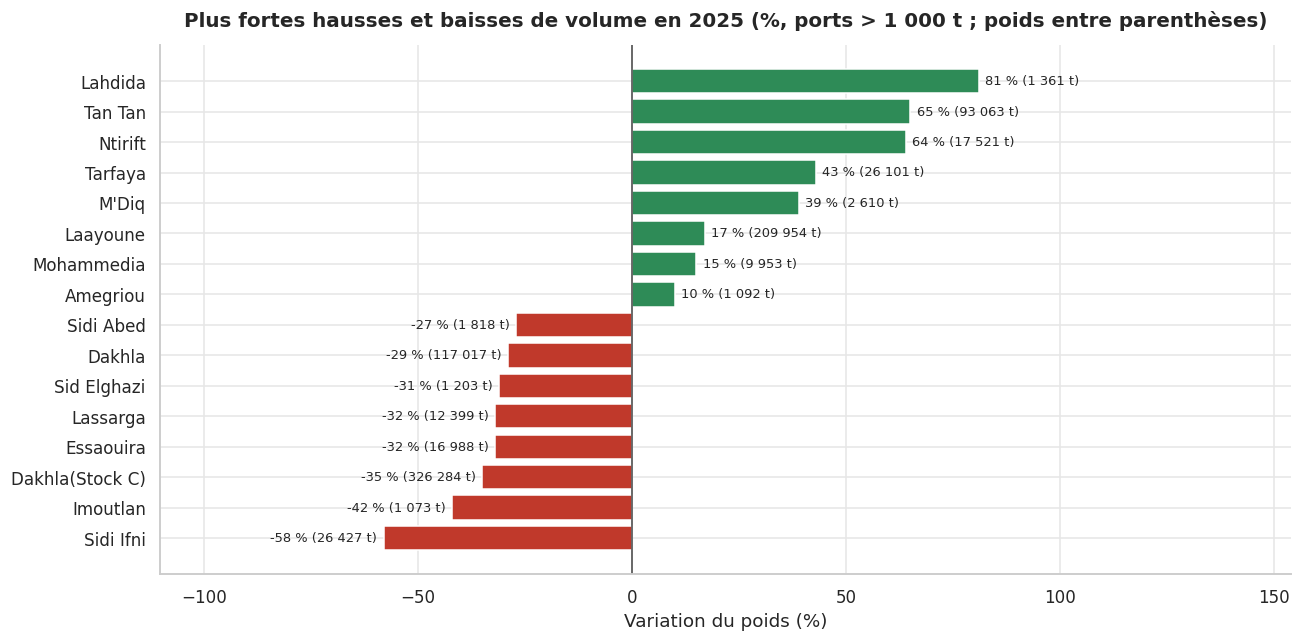

In [24]:
var = (ports[(ports["Annee"] == A_FIN) & (ports["Poids_Tonnes"] > 1000)]
       .dropna(subset=["Variation_Poids"]).sort_values("Variation_Poids"))
extremes = pd.concat([var.head(8), var.tail(8)])
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(extremes["Port"], extremes["Variation_Poids"], color=[ROUGE if v < 0 else VERT for v in extremes["Variation_Poids"]])
ax.axvline(0, color="#444444", lw=1)
for p_, (_, r) in zip(ax.patches, extremes.iterrows()):
    w = p_.get_width()
    ax.text(w + (1.5 if w >= 0 else -1.5), p_.get_y() + p_.get_height() / 2,
            f"{fr(w, 0)} % ({fr(r['Poids_Tonnes'], 0)} t)", va="center", ha="left" if w >= 0 else "right", fontsize=8.5)
ax.set_xlim(extremes["Variation_Poids"].min() * 1.9, extremes["Variation_Poids"].max() * 1.9)
ax.set_title(f"Plus fortes hausses et baisses de volume en {A_FIN} (%, ports > 1 000 t ; poids entre parenthèses)")
ax.set_xlabel("Variation du poids (%)")
plt.tight_layout()
plt.show()

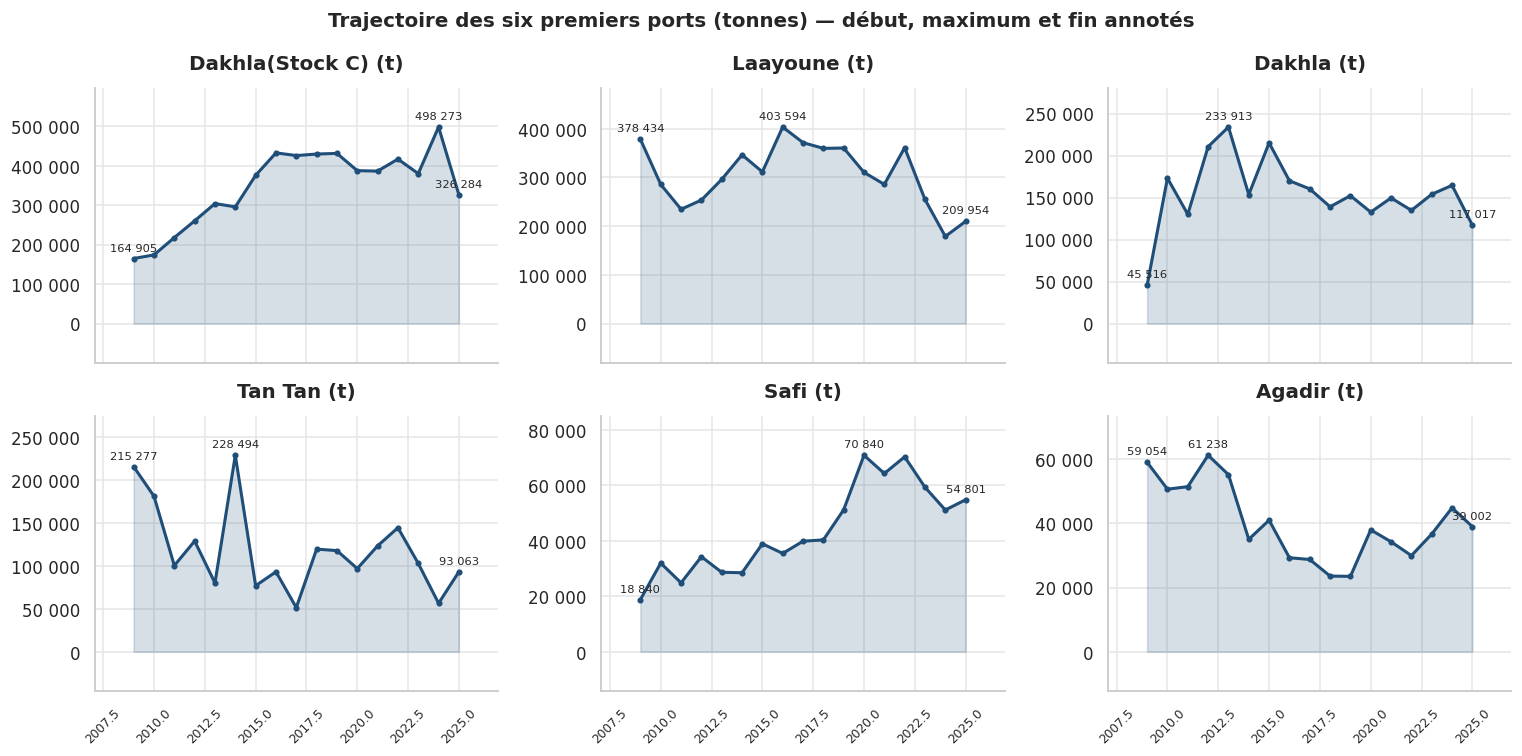

In [25]:
six = ports.groupby("Port")["Poids_Tonnes"].sum().nlargest(6).index
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True)
for ax, nom in zip(axes.ravel(), six):
    s = ports[ports["Port"] == nom].set_index("Annee")["Poids_Tonnes"].sort_index()
    ax.fill_between(s.index, s.values, color=BLEU, alpha=0.18)
    ax.plot(s.index, s.values, color=BLEU, lw=2, marker="o", ms=3)
    for xi in (s.index[0], s.idxmax(), s.index[-1]):
        ax.annotate(fr(s[xi], 0), (xi, s[xi]), xytext=(0, 5), textcoords="offset points", ha="center", fontsize=7.5)
    ax.yaxis.set_major_formatter(MILLIERS)
    ax.set_title(nom + " (t)")
    ax.margins(x=0.12, y=0.2)
    ax.tick_params(axis="x", rotation=45, labelsize=8)
fig.suptitle("Trajectoire des six premiers ports (tonnes) — début, maximum et fin annotés", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

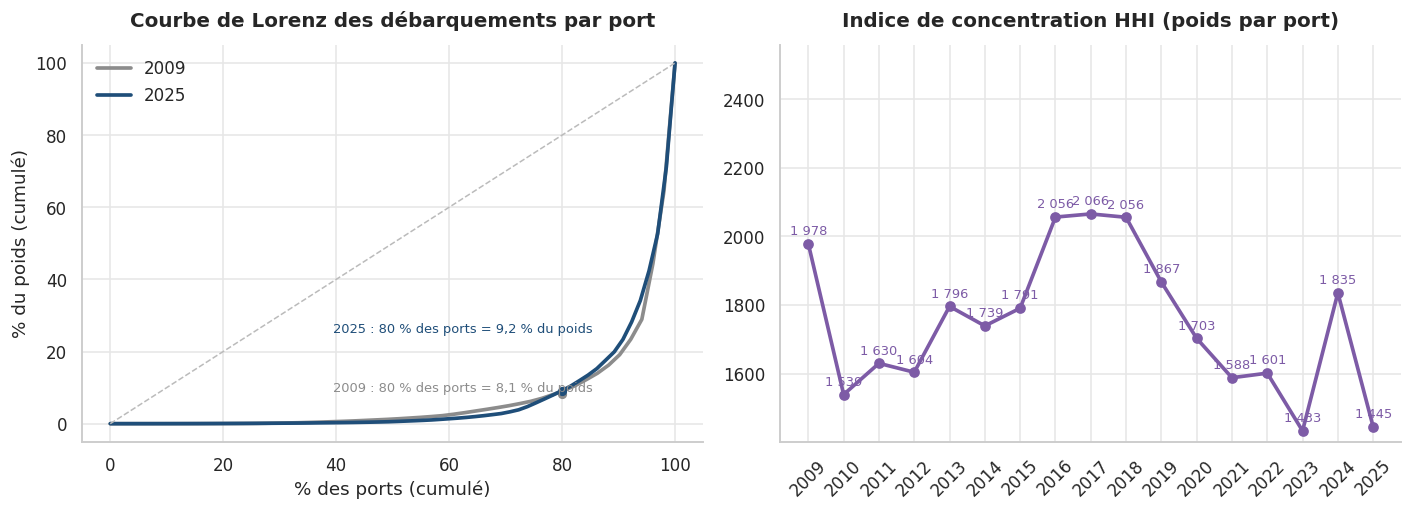

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for annee, coul, dy in [(A_DEB, GRIS, -28), (A_FIN, BLEU, 8)]:
    v = np.sort(ports.loc[ports["Annee"] == annee, "Poids_Tonnes"].values)
    cum = np.insert(np.cumsum(v) / v.sum(), 0, 0) * 100
    axes[0].plot(np.linspace(0, 100, len(cum)), cum, lw=2.4, color=coul, label=str(annee))
    bas80 = np.cumsum(v)[int(len(v) * 0.8) - 1] / v.sum() * 100
    axes[0].plot([80], [bas80], "o", color=coul, ms=5)
    axes[0].annotate(f"{annee} : 80 % des ports = {fr(bas80, 1)} % du poids", (80, bas80),
                     xytext=(-150, dy + 30), textcoords="offset points", fontsize=8.5, color=coul)
axes[0].plot([0, 100], [0, 100], ls="--", color="#bbbbbb", lw=1)
axes[0].set_title("Courbe de Lorenz des débarquements par port")
axes[0].set_xlabel("% des ports (cumulé)")
axes[0].set_ylabel("% du poids (cumulé)")
axes[0].legend(frameon=False)

serie_hhi = ports.groupby("Annee")["Poids_Tonnes"].apply(hhi)
axes[1].plot(serie_hhi.index, serie_hhi.values, color=VIOLET, marker="o", lw=2.4)
etiquettes_v(axes[1], serie_hhi.index, serie_hhi.values, couleur=VIOLET, rot=0, fs=8.5)
axes[1].set_title("Indice de concentration HHI (poids par port)")
axes[1].set_xticks(serie_hhi.index)
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

### 6.4 Régions maritimes

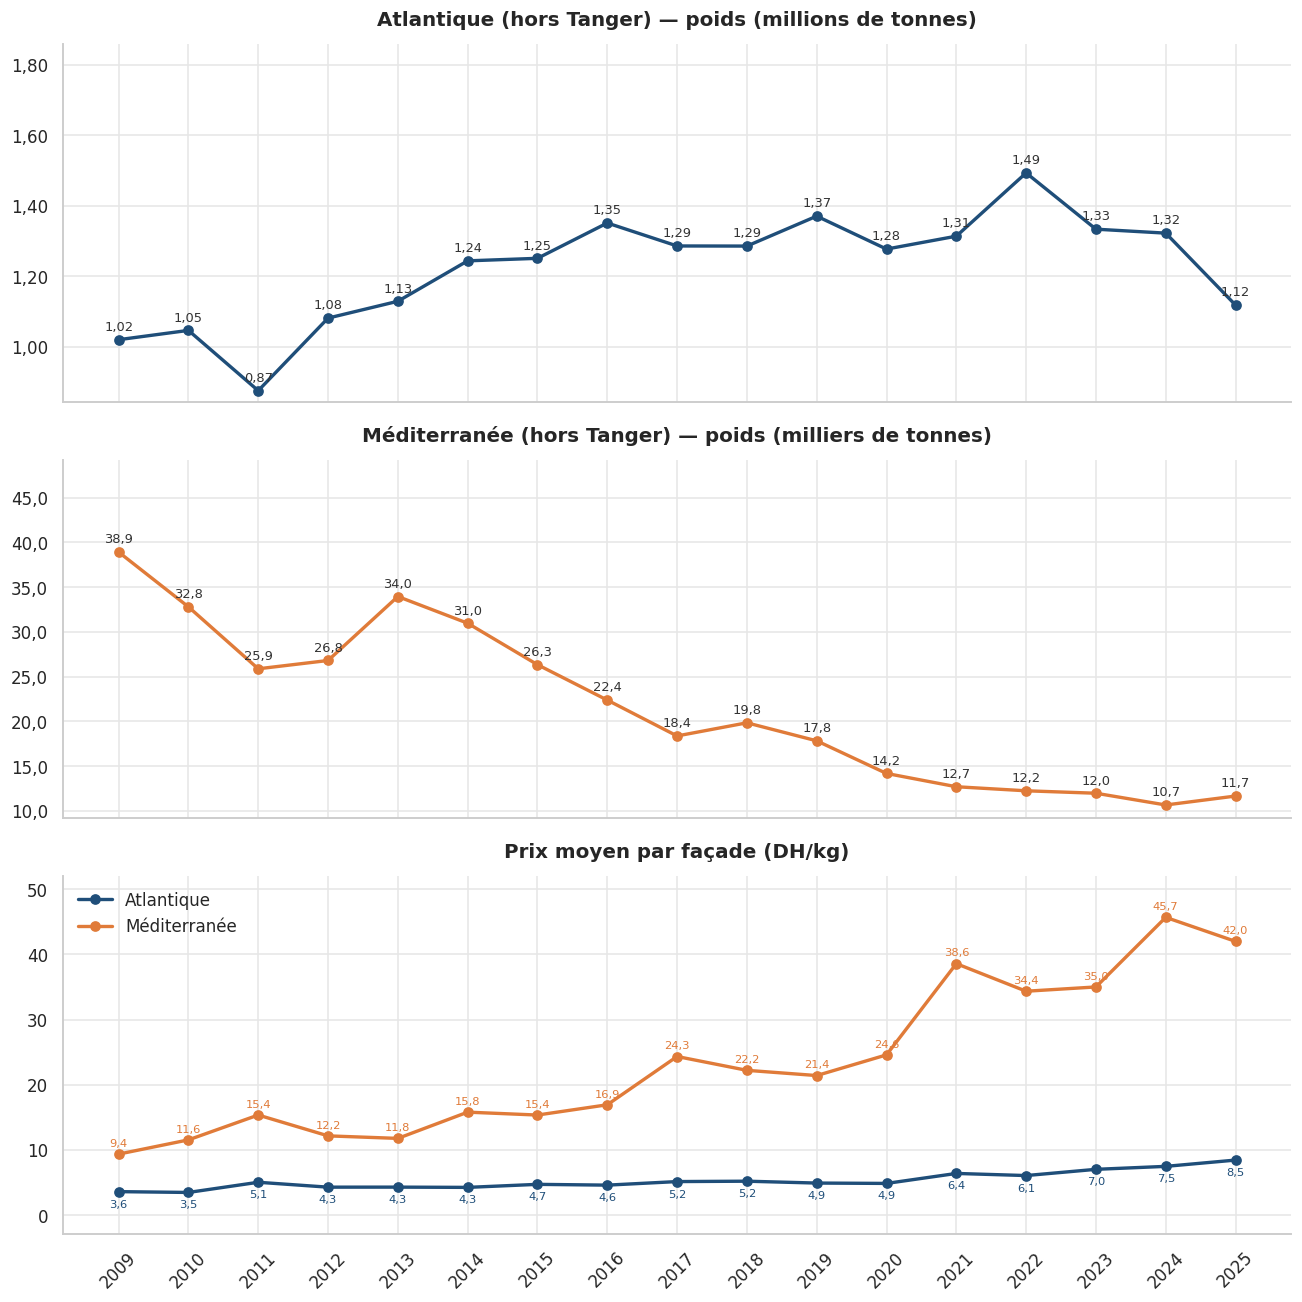

In [27]:
def agg_region(masque):
    d = ports[masque].groupby("Annee")[["Poids_Tonnes", "Valeur_KDH"]].sum()
    d["Valeur_MDH"] = d["Valeur_KDH"] / 1000
    d["Prix"] = d["Valeur_KDH"] / d["Poids_Tonnes"]
    return d

med_ht = agg_region(ports["Cle_Port"].isin(PORTS_MEDITERRANEE) & (ports["Cle_Port"] != "TANGER"))
atl = agg_region(~ports["Cle_Port"].isin(PORTS_MEDITERRANEE))

FORMAT_MT = mticker.FuncFormatter(lambda x, pos=None: fr(x, 2))
FORMAT_KT = mticker.FuncFormatter(lambda x, pos=None: fr(x, 1))

fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
axes[0].plot(atl.index, atl["Poids_Tonnes"] / 1e6, color=BLEU, marker="o", lw=2.2)
etiquettes_v(axes[0], atl.index, (atl["Poids_Tonnes"] / 1e6).values, dec=2, rot=0, fs=8.5)
axes[0].yaxis.set_major_formatter(FORMAT_MT)
axes[0].set_title("Atlantique (hors Tanger) — poids (millions de tonnes)")
axes[1].plot(med_ht.index, med_ht["Poids_Tonnes"] / 1e3, color=ORANGE, marker="o", lw=2.2)
etiquettes_v(axes[1], med_ht.index, (med_ht["Poids_Tonnes"] / 1e3).values, dec=1, rot=0, fs=8.5)
axes[1].yaxis.set_major_formatter(FORMAT_KT)
axes[1].set_title("Méditerranée (hors Tanger) — poids (milliers de tonnes)")
axes[2].plot(atl.index, atl["Prix"], color=BLEU, marker="o", lw=2.2, label="Atlantique")
axes[2].plot(med_ht.index, med_ht["Prix"], color=ORANGE, marker="o", lw=2.2, label="Méditerranée")
for xi, yi in zip(atl.index, atl["Prix"]):
    axes[2].annotate(fr(yi, 1), (xi, yi), xytext=(0, -5), textcoords="offset points", ha="center", va="top", fontsize=7.5, color=BLEU)
for xi, yi in zip(med_ht.index, med_ht["Prix"]):
    axes[2].annotate(fr(yi, 1), (xi, yi), xytext=(0, 5), textcoords="offset points", ha="center", fontsize=7.5, color=ORANGE)
axes[2].set_title("Prix moyen par façade (DH/kg)")
axes[2].legend(frameon=False, loc="upper left")
axes[2].margins(y=0.15)
axes[2].set_xticks(atl.index)
axes[2].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

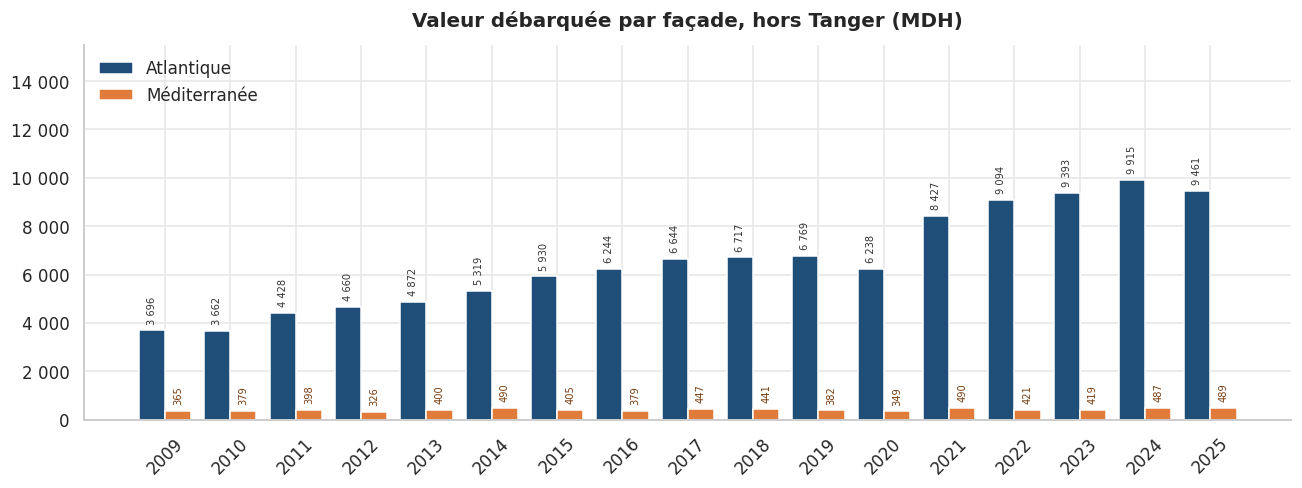

In [28]:
fig, ax = plt.subplots(figsize=(12, 4.6))
wd = 0.4
ax.bar(atl.index - wd / 2, atl["Valeur_MDH"], wd, color=BLEU, label="Atlantique")
ax.bar(med_ht.index + wd / 2, med_ht["Valeur_MDH"], wd, color=ORANGE, label="Méditerranée")
etiquettes_v(ax, atl.index - wd / 2, atl["Valeur_MDH"].values, fs=6.5)
etiquettes_v(ax, med_ht.index + wd / 2, med_ht["Valeur_MDH"].values, fs=6.5, couleur="#7a3d10")
ax.yaxis.set_major_formatter(MILLIERS)
ax.set_title("Valeur débarquée par façade, hors Tanger (MDH)")
ax.legend(frameon=False, loc="upper left")
ax.set_xticks(atl.index)
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

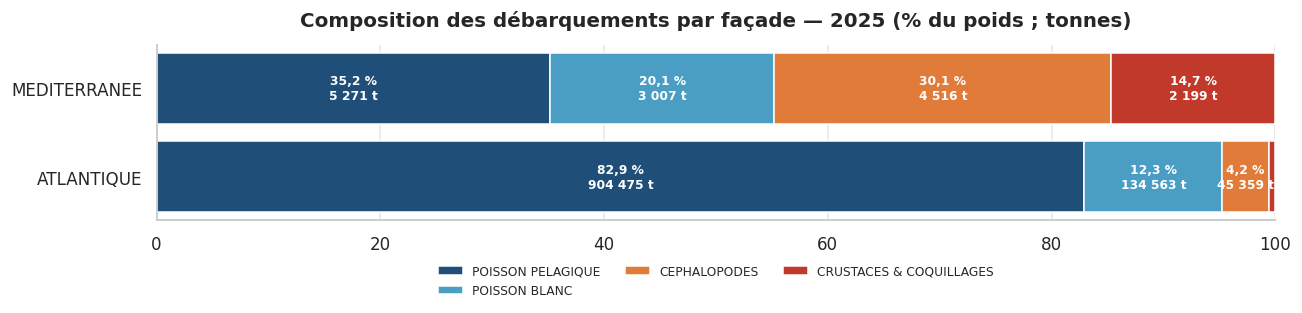

In [29]:
struct = (groupes[groupes["Annee"] == A_FIN]
          .pivot_table(index="Region", columns="Groupe", values="Poids_Tonnes", aggfunc="sum").fillna(0))
struct_pct = struct.div(struct.sum(axis=1), axis=0) * 100
cols = [c for c in ORDRE_GROUPES if c in struct_pct.columns]

fig, ax = plt.subplots(figsize=(12, 3.6))
gauche = np.zeros(len(struct_pct))
for c in cols:
    ax.barh(struct_pct.index, struct_pct[c], left=gauche, color=COUL_GROUPE[c], label=c)
    for i, (val, g0) in enumerate(zip(struct_pct[c].values, gauche)):
        if val >= 4:
            ax.text(g0 + val / 2, i, f"{fr(val, 1)} %\n{fr(struct.loc[struct_pct.index[i], c], 0)} t",
                    ha="center", va="center", color="white", fontsize=8, fontweight="bold")
    gauche += struct_pct[c].values
ax.set_title(f"Composition des débarquements par façade — {A_FIN} (% du poids ; tonnes)")
ax.set_xlim(0, 100)
ax.legend(ncol=3, fontsize=8, loc="lower center", bbox_to_anchor=(0.5, -0.5), frameon=False)
plt.tight_layout()
plt.show()

### 6.5 Espèces (détail disponible 2009–2016)

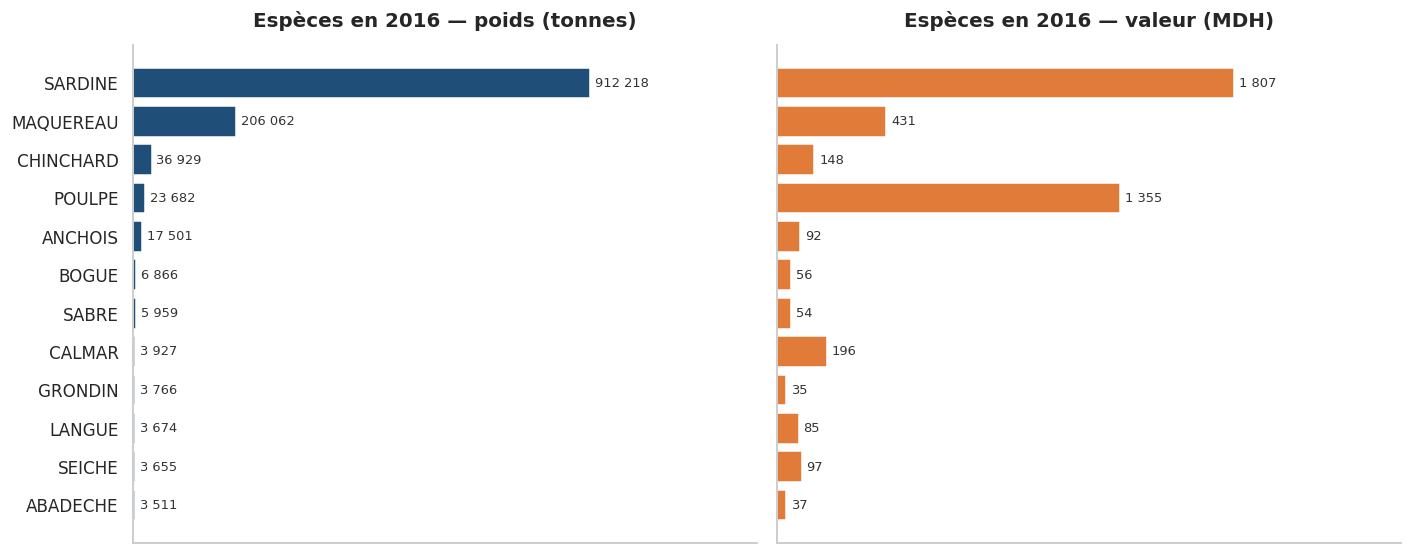

In [30]:
t = top_especes.sort_values("Poids_Tonnes")
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), sharey=True)
axes[0].barh(t["Espece"], t["Poids_Tonnes"], color=BLEU)
axes[0].set_title(f"Espèces en {A_ESP} — poids (tonnes)")
axes[1].barh(t["Espece"], t["Valeur_MDH"], color=ORANGE)
axes[1].set_title(f"Espèces en {A_ESP} — valeur (MDH)")
etiquettes_h(axes[0], lambda p, i: fr(p.get_width(), 0))
etiquettes_h(axes[1], lambda p, i: fr(p.get_width(), 0))
plt.tight_layout()
plt.show()

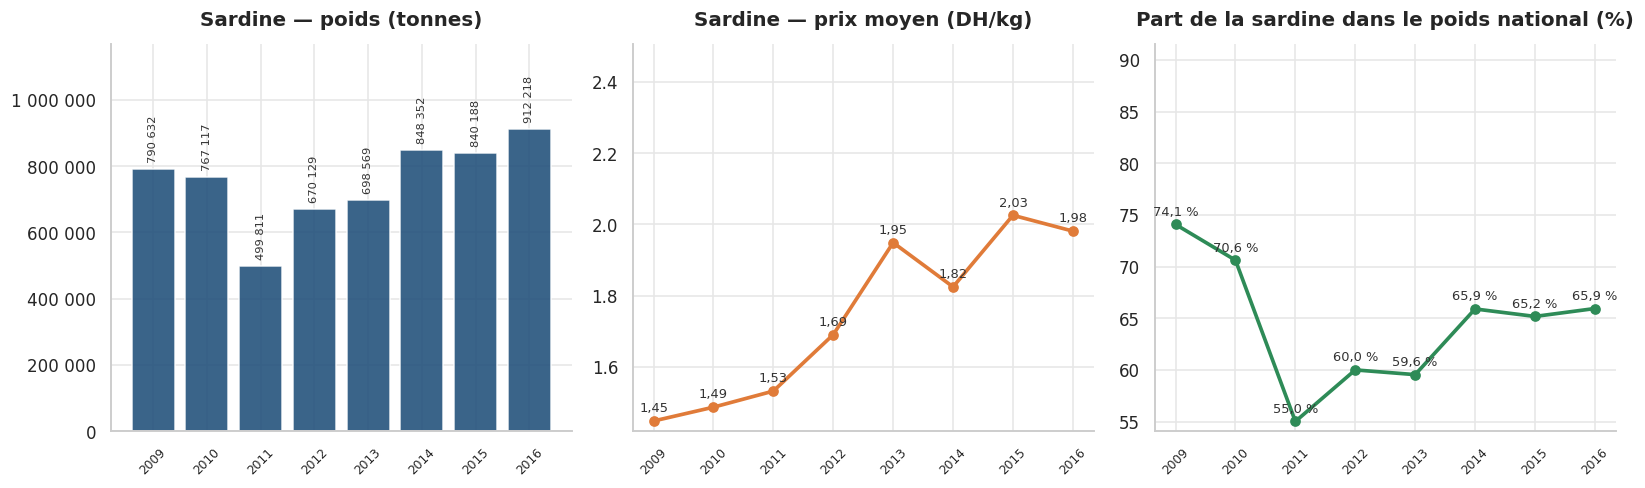

In [31]:
sardine = especes[especes["Espece"] == "SARDINE"].set_index("Annee").sort_index()
part = 100 * sardine["Poids_Tonnes"] / national.loc[sardine.index, "Poids_Tonnes"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
axes[0].bar(sardine.index, sardine["Poids_Tonnes"], color=BLEU, alpha=0.88)
etiquettes_v(axes[0], sardine.index, sardine["Poids_Tonnes"].values)
axes[0].yaxis.set_major_formatter(MILLIERS)
axes[0].set_title("Sardine — poids (tonnes)")
axes[1].plot(sardine.index, sardine["Prix_DH_kg"], color=ORANGE, marker="o", lw=2.4)
etiquettes_v(axes[1], sardine.index, sardine["Prix_DH_kg"].values, dec=2, rot=0, fs=8.5)
axes[1].set_title("Sardine — prix moyen (DH/kg)")
axes[2].plot(part.index, part.values, color=VERT, marker="o", lw=2.4)
etiquettes_v(axes[2], part.index, part.values, dec=1, rot=0, fs=8.5, suffixe=" %")
axes[2].set_title("Part de la sardine dans le poids national (%)")
for a in axes:
    a.tick_params(axis="x", rotation=45, labelsize=8)
plt.tight_layout()
plt.show()

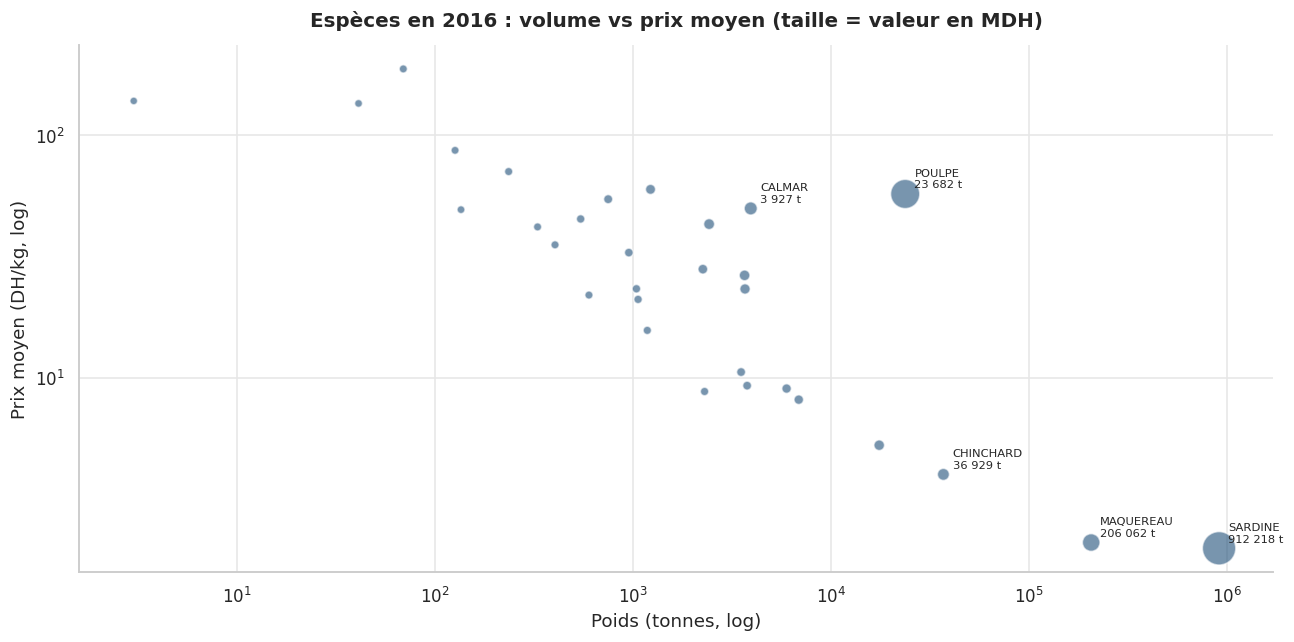

In [32]:
e = especes[(especes["Annee"] == A_ESP) & (especes["Poids_Tonnes"] > 0)]
fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(e["Poids_Tonnes"], e["Prix_DH_kg"], s=e["Valeur_MDH"] / 4 + 25, color=BLEU, alpha=0.6, edgecolor="white")
for _, r in e.nlargest(5, "Valeur_MDH").iterrows():
    ax.annotate(f"{r['Espece']}\n{fr(r['Poids_Tonnes'], 0)} t",
                (r["Poids_Tonnes"], r["Prix_DH_kg"]), fontsize=7.5, xytext=(6, 4), textcoords="offset points")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title(f"Espèces en {A_ESP} : volume vs prix moyen (taille = valeur en MDH)")
ax.set_xlabel("Poids (tonnes, log)")
ax.set_ylabel("Prix moyen (DH/kg, log)")
plt.tight_layout()
plt.show()

## 7. Conclusion

In [33]:
synthese = pd.DataFrame({
    "Indicateur": [
        f"Poids débarqué {A_DEB}", f"Poids débarqué {A_FIN}", "TCAM poids",
        f"Valeur {A_DEB}", f"Valeur {A_FIN}", "TCAM valeur",
        f"Prix moyen {A_DEB}", f"Prix moyen {A_FIN}",
        f"Part poisson pélagique {A_FIN}", f"Premier port {A_FIN}",
    ],
    "Valeur": [
        f"{fr(national.loc[A_DEB, 'Poids_Tonnes'], 0)} t",
        f"{fr(national.loc[A_FIN, 'Poids_Tonnes'], 0)} t",
        f"{fr(tcam(national['Poids_Tonnes']))} % / an",
        f"{fr(national.loc[A_DEB, 'Valeur_MDH'], 0)} MDH",
        f"{fr(national.loc[A_FIN, 'Valeur_MDH'], 0)} MDH",
        f"{fr(tcam(national['Valeur_KDH']))} % / an",
        f"{fr(national.loc[A_DEB, 'Prix_DH_kg'])} DH/kg",
        f"{fr(national.loc[A_FIN, 'Prix_DH_kg'])} DH/kg",
        f"{fr(bilan_groupes.loc['POISSON PELAGIQUE', 'Part_poids_%'], 1)} %",
        f"{top_ports.loc[0, 'Port']} ({fr(top_ports.loc[0, 'Part_%'], 1)} % du total)",
    ],
})
synthese

,Indicateur,Valeur
0,Poids débarqué 2009,1 067 276 t
1,Poids débarqué 2025,1 132 802 t
2,TCAM poids,"0,37 % / an"
3,Valeur 2009,4 256 MDH
4,Valeur 2025,10 112 MDH
5,TCAM valeur,"5,56 % / an"
6,Prix moyen 2009,"3,99 DH/kg"
7,Prix moyen 2025,"8,93 DH/kg"
8,Part poisson pélagique 2025,"82,3 %"
9,Premier port 2025,"Dakhla(Stock C) (28,8 % du total)"


### Ce que montrent les données

- **Volumes stables, valeur en forte hausse** : le tonnage progresse lentement sur la période alors que la valeur débarquée croît nettement plus vite. La croissance est donc portée par le **prix moyen au kilo**, pas par l'effort de pêche.
- **Un secteur dominé par le pélagique** : le poisson pélagique (sardine en tête) représente l'essentiel du tonnage mais une part beaucoup plus faible de la valeur ; céphalopodes et crustacés font l'inverse — faibles volumes, prix unitaires élevés.
- **Forte concentration géographique** : l'indice HHI et la courbe de Lorenz montrent qu'une poignée de ports atlantiques du Sud (Dakhla, Laâyoune, Tan Tan, Boujdour) concentre la majorité des débarquements ; la Méditerranée pèse environ 1 % du tonnage national et son poids relatif décline.
- **Prix moyen plus élevé en Méditerranée**, cohérent avec un mix d'espèces plus orienté poisson blanc et céphalopodes.

### Limites

1. Le détail **par espèce s'arrête en 2016** : après cette date l'ONP ne publie plus que les groupes d'espèces, ce qui interdit un suivi de la sardine seule sur la période récente.
2. Les fichiers **crustacés** / **coquillages** ne sont séparés que sur quelques années ; ils sont ici consolidés en un seul groupe.
3. **Tanger** change de façade entre les rapports ≤ 2016 (Atlantique) et ≥ 2017 (Méditerranée) — corrigé ici, mais à garder en tête pour toute comparaison avec les rapports d'origine.
4. Les chiffres de la dernière année sont ceux publiés dans le rapport le plus récent et peuvent être **révisés** dans l'édition suivante (l'ONP révise régulièrement l'année n-1).
5. Les tableaux **mensuels** des rapports n'ont pas été extraits : aucune analyse de saisonnalité n'est possible ici.